# Daniyal Khan || 221A061 || 19

## Step 1 — Install / Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version :", tf.__version__)
print("GPU available       :", len(tf.config.list_physical_devices('GPU')) > 0)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version : 2.19.0
GPU available       : True


## Step 2 — Load & Preprocess CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training samples  : (10000, 32, 32, 3)
Test samples      : (2000, 32, 32, 3)


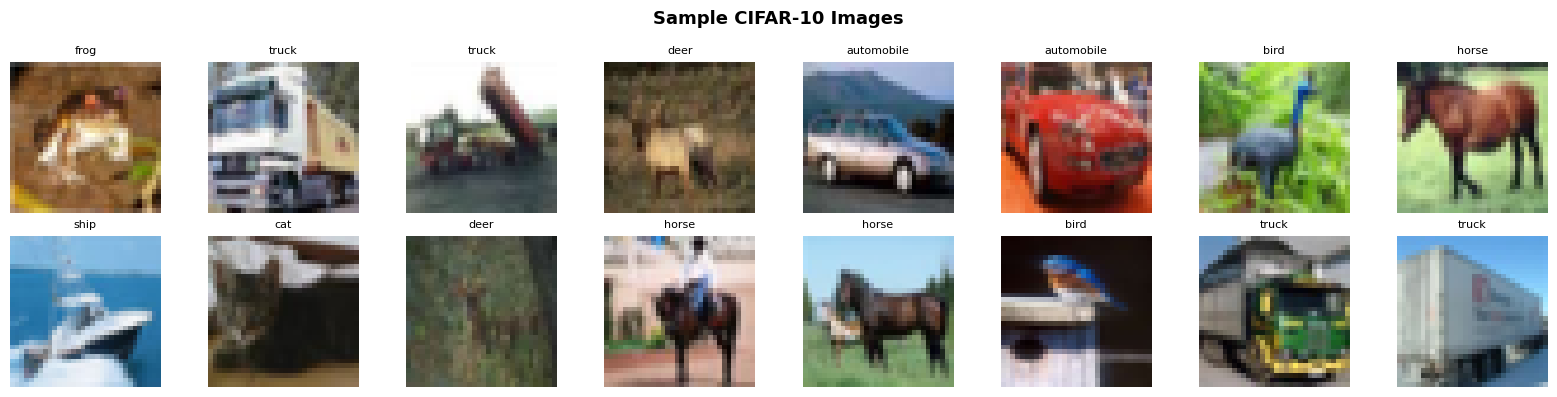

In [ ]:
# ── CIFAR-10: 60 000 colour images, 32×32, 10 classes ──────────────────────
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
NUM_CLASSES  = 10
IMG_SIZE     = 96          # MobileNetV2 min input is 96×96
BATCH_SIZE   = 64

(x_train, y_train_raw), (x_test, y_test_raw) = keras.datasets.cifar10.load_data()

# Normalise to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Flatten label arrays
y_train = y_train_raw.flatten()
y_test  = y_test_raw.flatten()

# Use a subset to keep Colab training time reasonable
TRAIN_SAMPLES = 10000
TEST_SAMPLES  = 2000

x_train, y_train = x_train[:TRAIN_SAMPLES], y_train[:TRAIN_SAMPLES]
x_test,  y_test  = x_test[:TEST_SAMPLES],   y_test[:TEST_SAMPLES]

print(f"Training samples  : {x_train.shape}")
print(f"Test samples      : {x_test.shape}")

# ── Quick peek at sample images ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3 — Build tf.data Pipelines with Augmentation

In [ ]:
# Data augmentation layer (applied only during training)
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='augmentation')

def preprocess(image, label, training=False):
    """Resize to IMG_SIZE and optionally augment."""
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # MobileNetV2 expects inputs in [-1, 1] via preprocess_input
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
    if training:
        image = augment(image, training=True)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(TRAIN_SAMPLES)
            .map(lambda x, y: preprocess(x, y, training=True),  num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
            .map(lambda x, y: preprocess(x, y, training=False), num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print('Pipeline ready. Batch shape:', next(iter(train_ds))[0].shape)

Pipeline ready. Batch shape: (64, 96, 96, 3)


## Step 4 — Build Models

We build **three** models for comparison:

| Model | Pretrained Weights | Base Frozen? |
|---|---|---|
| **Scratch** | None | — |
| **Feature Extraction** | ImageNet | ✅ All frozen |
| **Fine-Tuning** | ImageNet | ❌ Top 30 layers unfrozen |

In [ ]:
def build_head(base_output):
    """Shared classification head added on top of any base."""
    x = layers.GlobalAveragePooling2D()(base_output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return out


# ── MODEL A: Train From Scratch (MobileNetV2 architecture, random weights) ──
base_scratch = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights=None          # <-- no pretrained weights
)
out_scratch  = build_head(base_scratch.output)
model_scratch = Model(inputs=base_scratch.input, outputs=out_scratch, name='Scratch')
model_scratch.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ── MODEL B: Feature Extraction (all MobileNetV2 layers frozen) ─────────────
base_fe = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'    # <-- pretrained
)
base_fe.trainable = False   # freeze entire base

out_fe   = build_head(base_fe.output)
model_fe = Model(inputs=base_fe.input, outputs=out_fe, name='FeatureExtraction')
model_fe.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ── MODEL C: Fine-Tuning (top 30 MobileNetV2 layers unfrozen) ───────────────
base_ft = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
# First freeze all, then unfreeze the top 30 layers
base_ft.trainable = False
for layer in base_ft.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

out_ft   = build_head(base_ft.output)
model_ft = Model(inputs=base_ft.input, outputs=out_ft, name='FineTuning')
model_ft.compile(
    optimizer=Adam(1e-4),   # lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ── Summary ──────────────────────────────────────────────────────────────────
def param_summary(model):
    total     = model.count_params()
    trainable = sum([tf.size(v).numpy() for v in model.trainable_variables])
    frozen    = total - trainable
    print(f"  {model.name:<22}  total={total:>8,}  trainable={trainable:>8,}  frozen={frozen:>8,}")

print("\nParameter counts:")
print("-" * 70)
for m in [model_scratch, model_fe, model_ft]:
    param_summary(m)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Parameter counts:
----------------------------------------------------------------------
  Scratch                 total=2,593,610  trainable=2,556,938  frozen=  36,672
  FeatureExtraction       total=2,593,610  trainable= 333,066  frozen=2,260,544
  FineTuning              total=2,593,610  trainable=1,843,786  frozen= 749,824


## Step 5 — Train All Three Models

In [ ]:
EPOCHS = 15

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1)
]

# ── Train Scratch ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print(" Training Model A — From Scratch")
print("="*60)
hist_scratch = model_scratch.fit(
    train_ds, validation_data=test_ds,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

# ── Train Feature Extraction ─────────────────────────────────────────────────
print("\n" + "="*60)
print(" Training Model B — Feature Extraction")
print("="*60)
hist_fe = model_fe.fit(
    train_ds, validation_data=test_ds,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

# ── Train Fine-Tuning ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print(" Training Model C — Fine-Tuning")
print("="*60)
hist_ft = model_ft.fit(
    train_ds, validation_data=test_ds,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

## Step 6 — Evaluate & Compare

In [ ]:
results = {}
for name, model in [('Scratch', model_scratch),
                     ('Feature Extraction', model_fe),
                     ('Fine-Tuning', model_ft)]:
    loss, acc = model.evaluate(test_ds, verbose=0)
    results[name] = {'loss': loss, 'accuracy': acc}
    print(f"{name:<22}  loss={loss:.4f}  accuracy={acc:.4f}")

print("\n✅ Best model:",
      max(results, key=lambda k: results[k]['accuracy']))

Scratch                 loss=2.4649  accuracy=0.1085
Feature Extraction      loss=0.5272  accuracy=0.8330
Fine-Tuning             loss=0.4394  accuracy=0.8600

✅ Best model: Fine-Tuning


## Step 7 — Visualise Training Curves

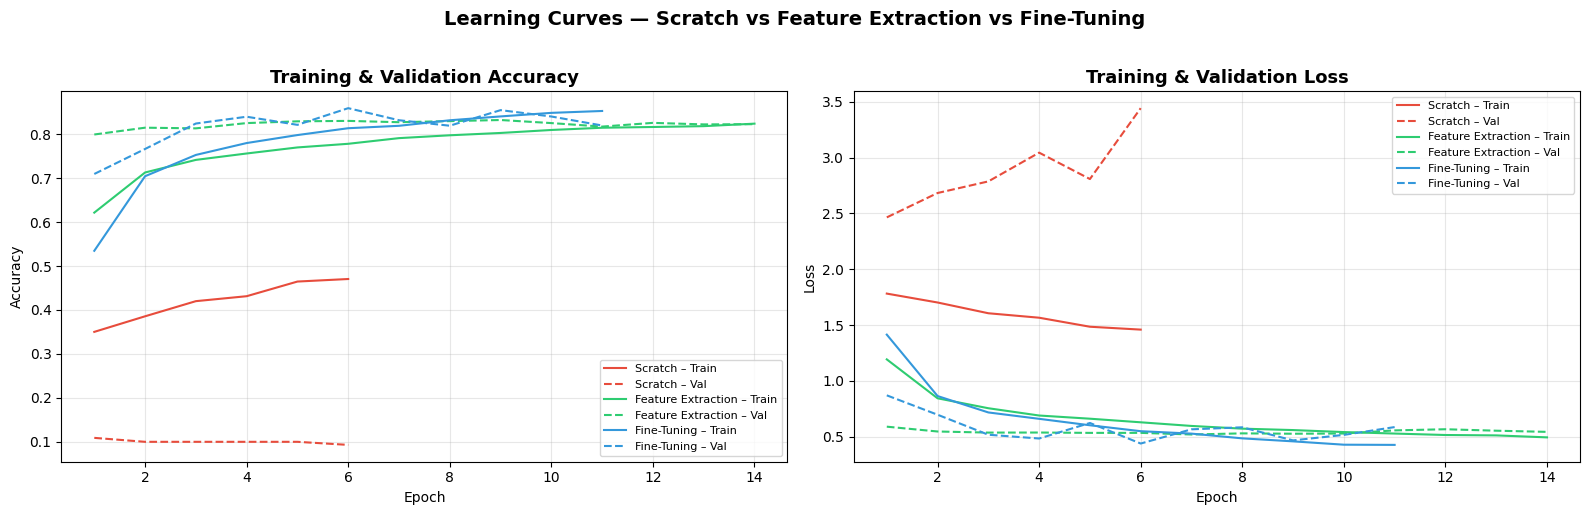

In [ ]:
def plot_history(histories, labels, colors):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for hist, label, color in zip(histories, labels, colors):
        epochs = range(1, len(hist.history['accuracy']) + 1)
        # Accuracy
        axes[0].plot(epochs, hist.history['accuracy'],     color=color, linestyle='-',  label=f'{label} – Train')
        axes[0].plot(epochs, hist.history['val_accuracy'], color=color, linestyle='--', label=f'{label} – Val')
        # Loss
        axes[1].plot(epochs, hist.history['loss'],         color=color, linestyle='-',  label=f'{label} – Train')
        axes[1].plot(epochs, hist.history['val_loss'],     color=color, linestyle='--', label=f'{label} – Val')

    axes[0].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Learning Curves — Scratch vs Feature Extraction vs Fine-Tuning',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_history(
    [hist_scratch, hist_fe, hist_ft],
    ['Scratch', 'Feature Extraction', 'Fine-Tuning'],
    ['#E74C3C', '#2ECC71', '#3498DB']
)

## Step 8 — Accuracy Bar Chart

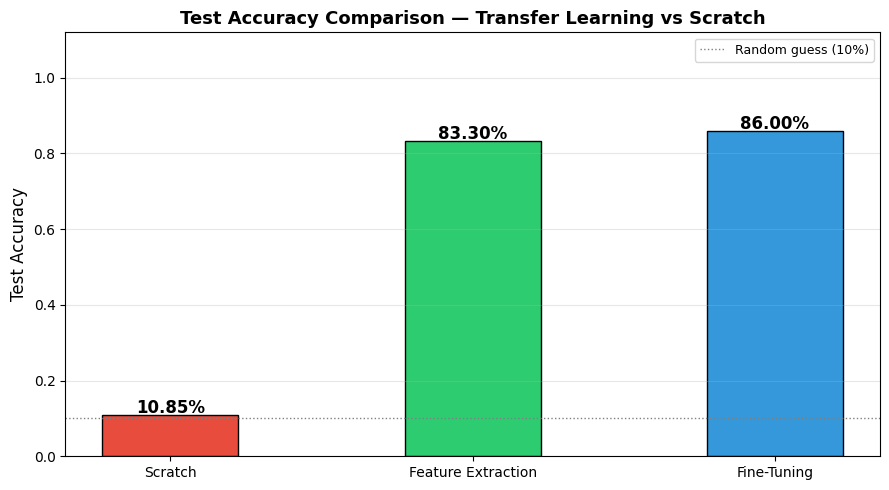

In [ ]:
model_labels = list(results.keys())
accuracies   = [results[k]['accuracy'] for k in model_labels]
colors_bar   = ['#E74C3C', '#2ECC71', '#3498DB']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_labels, accuracies, color=colors_bar, edgecolor='black', width=0.45)
for bar, v in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v*100:.2f}%", ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Test Accuracy Comparison — Transfer Learning vs Scratch',
             fontsize=13, fontweight='bold')
ax.axhline(0.1, color='grey', linestyle=':', linewidth=1, label='Random guess (10%)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9 — Confusion Matrix (Best Model)

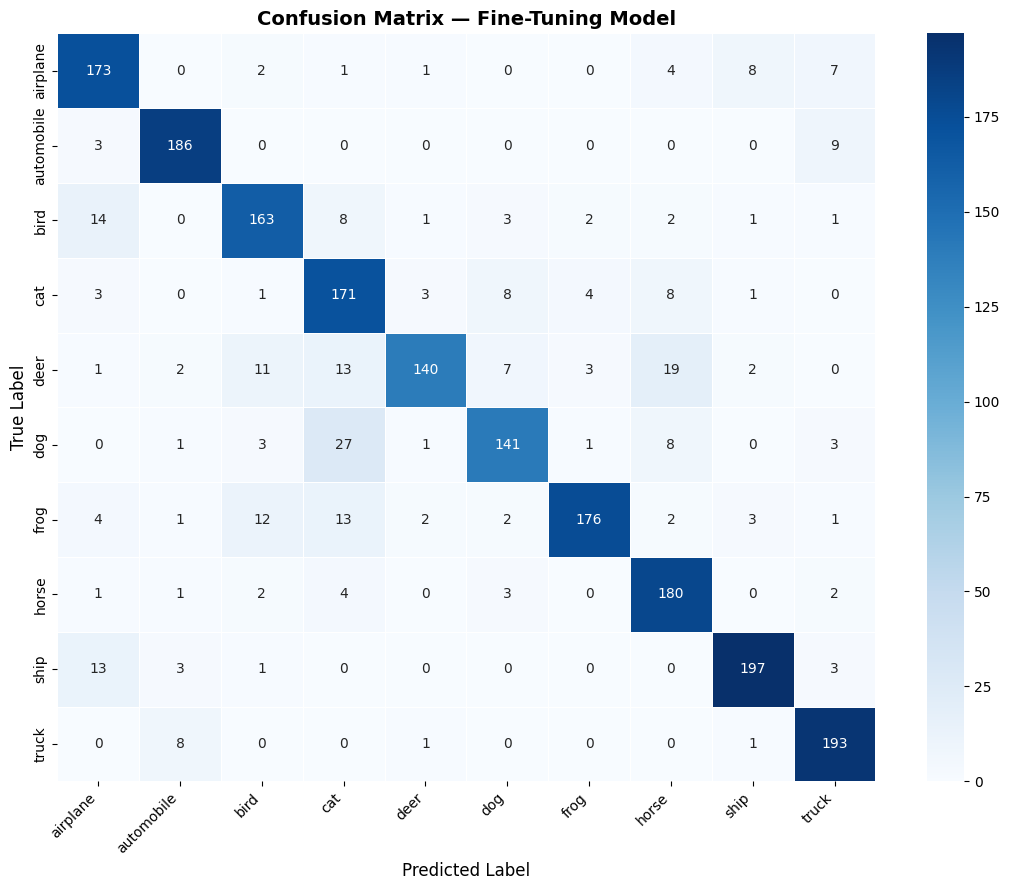


Classification Report — Fine-Tuning:
              precision    recall  f1-score   support

    airplane       0.82      0.88      0.85       196
  automobile       0.92      0.94      0.93       198
        bird       0.84      0.84      0.84       195
         cat       0.72      0.86      0.78       199
        deer       0.94      0.71      0.81       198
         dog       0.86      0.76      0.81       185
        frog       0.95      0.81      0.88       216
       horse       0.81      0.93      0.87       193
        ship       0.92      0.91      0.92       217
       truck       0.88      0.95      0.91       203

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.86      0.86      2000



In [ ]:
# Identify best model
best_name  = max(results, key=lambda k: results[k]['accuracy'])
best_model = {'Scratch': model_scratch,
              'Feature Extraction': model_fe,
              'Fine-Tuning': model_ft}[best_name]

# Get all predictions
y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            linewidths=0.5)
ax.set_title(f'Confusion Matrix — {best_name} Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Per-class report
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))